# Modelling embedding model on CT

In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
import torch

from sentence_transformers import SentenceTransformer, SentenceTransformerModelCardData, SentenceTransformerTrainingArguments, SentenceTransformerTrainer
from sentence_transformers.evaluation import InformationRetrievalEvaluator, SequentialEvaluator
from sentence_transformers.util import cos_sim
from sentence_transformers.losses import MatryoshkaLoss, MultipleNegativesRankingLoss
from sentence_transformers.training_args import BatchSamplers

from datasets import load_dataset, concatenate_datasets, Dataset

from tqdm.auto import tqdm
import regex as re
import os

In [ ]:
torch.cuda.empty_cache()

In [ ]:
#!pip install sentence_transformers
import os
os.getcwd()

'/content'

### **Load data from hugginface and preprocess, train-test split, pre-process**

Embedding model training requires a few unique dataset structures. A more detailed overview can be sound in the sentence transformers dataset documentation, but the 4 most popular formats are:

1.  Positive Pair: A pair of related sentences.
2.  Triplets: An anchor, positive, and negative
3.  Pair with Similarity Score: A pair of sentences with a score indicating their similarity
4.  Texts with Classes: A text with its corresponding class.

The structure of these datasets are what aids in the embedding model training, generally optimizing towards being able to accurately represent similar texts together

ALthough 1st and 2nd types are both quite popular with sentence embeddings, we'll use **Positive_pair data**(1st type) and our data is related to **Clinical trials**. We'll be using dataset from :- **[vab46/Clinical_trials_anchor-positive-pairs_EmbeddingModel-data](https://huggingface.co/datasets/vab46/Clinical_trials_anchor-positive-pairs_EmbeddingModel-data)** on huggingface. The data consist of synthetic Questions(anchor) genertaed from positive chunk-->7993 records(discussed in previous data generation files-->**embed_model_data_pre.ipynb, RAG_retrieval_finetuning_dataPrep.ipynb**).

In [ ]:
from datasets import load_dataset
import pandas as pd

The train_data preparation has been discussed in file:- **"RAG_retrieval_finetuning_dataPrep.ipynb"** and the data was pushed to hugginface hub.
1.  Copy the universal **HF_TOKEN**(generated by access tokens drop_down on profile logo on top right of huggingface account) up in secret side_panel of colab after add new key section.
2.  while pasting the value should **name and value** fields must have **'HF_TOKEN' and 'token_id' (generated in huggingface)**

3.  Since we are reading(here) and writing(when pushed data previuosly data):- access_key creation must have **preset:-Write(covers both read and write)**

In [ ]:
repo_path = "vab46/Clinical_trials_anchor-positive-pairs_EmbeddingModel-data2"
dataset = load_dataset(repo_path, split="train")

In [ ]:
len(dataset), type(dataset), dataset.column_names

(8744,
 datasets.arrow_dataset.Dataset,
 ['anchor_id',
  'nctId',
  'chunk_type',
  'block_no',
  'document_id',
  'anchor_type',
  'anchor',
  'positive',
  'chunk_char_length',
  'unique_chunk_identifier',
  'status'])

For the **new_data** and the final iteration of modelling on **refined/old data** the 1st if clause used; the elif handles initial iterations on old data.

### **Note**:-<u>Going forward in this notebook, following references are *impicable by comments, texts containing old data(iter1 and 2) and new data(iter1 and 2)*</u>:-
- **Old data**:-the *4 synthetic anchors mapped to (generated from) 1 consolidated chunk/positive(title +summary+ inclusion criteria)* per trial record(unique nctId). Coarser but semantically strong one to one anchor-positive pair mapping.
    - It has 2 iterations(<u>iter1:- the oldest iterations</u>) and iter2(<u>the final iteration of data generation and modelling:-best_model</u>)

    - The ***relevant_document*** consist on mapping between *row_id* and *global_chunk_id* in both iterations.
    - The [model](https://huggingface.co/vab46/nomic-embed-text-v1.5_Clinical-Trials_Matryoshka) for iter1 can be refrred by link. Simlarly is case for iter2(final version), [final model](https://huggingface.co/vab46/nomic-embed-text-v1.5_Clinical-Trials_Matryoshka_final) ---> all present on **huggingface hub**.   
    - The **iter1** and **iter2(final model)** results are present in :- **4anchor_1chunk_newAppr_base_ft_comparison_100step.xlsx** and **4anchor_1chunk_Cleanedfinal_base_ft_comparison_epoch.xlsx** respectively.

- **new data**:- the *5 synthetic anchors mapped to (generated from) 3 chunks /positive(title-->1, summary-->2, inclusion criteria-->2 individually)* per trial record(unique nctId). Finer and more directed, precise one to one anchor-positive pair mapping.
    - It has 2 iterations iteration1 and iter2.
    - Two iterations done with differnce being orienation of relevant_documents. In 1st iteration, *row_id* and *unique_chunk_identifier* was done. In 2nd iteration, *row_id* and *document_id(nctId+block_no)* was done.
    - The [model](https://huggingface.co/vab46/nomic-embed-text-v1.5_Clinical-Trials_Matryoshka2) for iter1 can be refrred by link. The iter 2 model yeilded below par results so did't save those. 
    - The **iter1** and **iter2(final model)** results are present combined in :- **5anchor_3chunk_iter1-2_base_ft_comparison.xlsx**

In [ ]:
# Clean & Format Columns
if(re.search("data2$", repo_path)):#new data and old data final iteration
  dataset = dataset.rename_column("anchor_id", "id")
  dataset = dataset.rename_column("unique_chunk_identifier", "global_chunk_id")

  #remove 'document_id' and create map in iter2, ignoresame in iter1 for===>(3 anchor_5 chunk new data)
  dataset = dataset.remove_columns(['nctId', 'block_no', 'chunk_type', 'anchor_type', 'chunk_char_length', 'status'])

elif(re.search("data$", repo_path)):
  dataset = dataset.rename_column("question", "anchor")
  dataset = dataset.rename_column("Positive_chunks", "positive")
  dataset = dataset.rename_column("__index_level_0__", "id")
  #dataset = dataset.rename_column("global_chunk_id", "document_id")

  dataset = dataset.remove_columns(['type', 'chunk_char_len', 'status']) # keep global_chunk_id

In [ ]:
dataset[0]

{'id': 8288,
 'document_id': 'NCT07758127_2',
 'anchor': 'Who are the patients with breast carcinoma being studied in this trial?',
 'positive': '* To evaluate HER2 expression in breast carcinoma with emphasizing HER2-ultralow, and HER2-low, HER2 equivocal tumors.\n* To correlate the results of HER2 with clinico-pathological prognostic parameters; examples tumor grade, Ki-67 proliferation index, nodal status, tumor size, lympho-vascular invasion, and perineural invasion, tumor infiltrating lymphocytes\n* To access interobserval agreement in HER2 score interpretation',
 'global_chunk_id': '1093ad3d1a7c64c5f4deffa2cbecaf6eae88b781352297d114fd06332c51bd77'}

*We'll shuffle the dataset and do 90:10 train_test split. This will aid easy loading and use for later metric calculations.*

In [ ]:
dataset =dataset.shuffle()

train_test_dataset = dataset.train_test_split(test_size=0.1)

#Save in json format
train_test_dataset["train"].to_json("train_data.json", orient="records")
train_test_dataset["test"].to_json("test_data.json", orient="records")

Creating json from Arrow format:   0%|          | 0/8 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

678510

In [ ]:
len(train_test_dataset['test']), len(train_test_dataset["train"])

(875, 7869)

In [ ]:
df_test = train_test_dataset["test"].to_pandas()
print(f"unique_chunks_ids----{df_test["global_chunk_id"].nunique()} and unique_chunks-----{df_test["positive"].nunique()}")

unique_chunks_ids----837 and unique_chunks-----837


We'll use **[InformationRetrieval evaluator](https://sbert.net/docs/package_reference/sentence_transformer/evaluation.html)** for base_model evaluation. It accepts 3 data structures:-

1.   Corpus dictionary:-mapping IDs to documents ({id: text_chunk})-->for both test and train data
2.   Query dictionary:- mapping IDs to questions ({id: question_text})-->for test data
3.   Relevant_documents:- Maps **id** for each test data anchors(query) with its **global_chunk_id/document_id** present in corpus(train & test data). In this way each anchor(~$a_i$~) gets linked with other anchor(~$a_j$~) given both of these have postive pairing with query(~$q_i$~).
  

### Note:-
  - on average 4 questions have been synthesized from one and only chunk for each clinical trial(refer data generation) for **old data(iter1)**. For the **new data(iter 2)**, each CT has been represented by 3 chunks which yeild different number of anchors(title--->1; summary--->2; inclusion_criteria--->2) totaling 5 per CT.
  
  - We want linkage of all possible test anchors with their chunk(global_chunk_id/document_id) multi-positioned at different indices of corpus(due 1-to-1 mapping in final train/test data):-
  
    - as final data had 1-to-1 anchor-pair map as elements.
    - dataset was scattered by ,shuffle()
    - to get **exhaustive anchor-positive pairs** map(for robust and generalized modelling) by *linking sibling anchors*(generated from common chunk) with one another.

  - Since ours is a optimization model(optimize embeddings cosines of our pre-trained model for existing clinical trials domain anchor-positives) and not typical discriminative-genreative (where generalization of model prediction on unkown/additional test input is measured):-
    - For corpus(chunk mapping) dictionary we are considering whole dataset despite query dictionary created from test set--->
      - (i)increase evaluation stringency that(iii) point talks.  
      - (ii)gives greater semantic robsutness when **anchors/queries align with semantically similar chunks to varying degree(helps during ranking during retrieval)**.
      - (iii)evaluator is able to measure against wide serachable corpus(with large hard & easy negative chunks for an question) instead of narrow which is easy. The wide searchable corpus gives **resileint metric like Recall@K, MRR@K, NDCG@K(we'll evaluate)**.

    - We have done **90:10 train-test split on anchors/questions rather than chunk level split** as:-
      - (i)former evaluates new question given similar chunk/corpus as same **global chunk id in both train-test** or conversly new question pointing to same CT corpus-->**intuitve for our domain specific(CT) retreival(domain related info datbase)**,
      - (ii) unlike latter which evaluates unknown questions given unknown unknown chunks
    



In [ ]:
# These contain pairs of questions (anchors) and text chunks (positives)
test_dataset = load_dataset("json", data_files="test_data.json", split="train")
train_dataset = load_dataset("json", data_files="train_data.json", split="train")

corpus_dataset = concatenate_datasets([train_dataset, test_dataset])# corpus =train+test combined

# Format: {query_id: question_text}
queries = dict(
    zip(test_dataset["id"], test_dataset["anchor"])
)

###Older approach:- (mapping row_ids--->chunks) for corpus and identifying relevant_doc(chunk) to test_anchor id by their id
'''
# Format: {corpus_id: text_chunk}
corpus = dict(
    zip(corpus_dataset["id"], corpus_dataset["positive"])
)

# Create a mapping between queries and their relevant documents
# This tells the evaluator which documents are correct matches for each query

relevant_docs = {}
for q_id, global_chunk_id in tqdm(zip(test_dataset["id"], test_dataset["global_chunk_id"])):
  #handles many Ques-to single chunk consequences(mentioned in prev block)
  if q_id not in relevant_docs:
    relevant_docs[q_id] = []

  matching_corpus_ids = [
      cid for cid, chunk in zip(corpus_dataset["id"], corpus_dataset["global_chunk_id"])
      if chunk == global_chunk_id
  ]
  # Add the matching corpus IDs to the relevant documents for this query
  relevant_docs[q_id].extend(matching_corpus_ids)

'''
###Newer approach:- altering the corpus(map by global_chunk_id) and identifying relevant_doc(chunk) to test_anchor id by common global_chun id

# Format: {corpus_id: text_chunk}
corpus = dict(
    zip(corpus_dataset["global_chunk_id"], corpus_dataset["positive"])
)

'''
#global_chunk_id(unique_chunk_identifier) to document_id(nctId_blockNo)====>iter2 (3 anchor_5 chunk new data)
global_chunk_doc_id_map ={}
for global_chunk_id, doc_id in tqdm(zip(corpus_dataset["global_chunk_id"], corpus_dataset["document_id"])):
    if(global_chunk_id not in global_chunk_doc_id_map):
        global_chunk_doc_id_map[global_chunk_id] = []


    if(doc_id not in global_chunk_doc_id_map[global_chunk_id]):#dupication of doc_id not allowed
        global_chunk_doc_id_map[global_chunk_id].append(doc_id)#

    global_chunk_doc_id_map[global_chunk_id].append(doc_id)#duplication of doc_id allowed
'''
#map anchor and chunk identifiers(to establish anchor-positive pair reltn for test set)
relevant_docs ={}
for q_id, global_chunk_id in tqdm(zip(test_dataset["id"], test_dataset["global_chunk_id"])):
  relevant_docs[q_id] = [global_chunk_id]#iter1(5 anchor_3 chunk new data)
  #relevant_docs[q_id] = global_chunk_doc_id_map[global_chunk_id]#iter2(3 anchor_5 chunk new data)




0it [00:00, ?it/s]

In [ ]:
print(len(set(relevant_docs.keys())), len(set([el[0] for el in relevant_docs.values()])))#iter1(4 anchor 1 consolidated chunk new data)

#iter2(3 anchor_5 chunk new data)
'''
ls_relevant_values_flattened=[]

for el in relevant_docs.values():
  ls_relevant_values_flattened.extend(el)

len(set(relevant_docs.keys())), len(set(ls_relevant_values_flattened)), len(ls_relevant_values_flattened)
'''

875 837


'\n#iter2(3 anchor_5 chunk new data)\nls_relevant_values_flattened=[]\n\nfor el in relevant_docs.values():\n  ls_relevant_values_flattened.extend(el)\n\nlen(set(relevant_docs.keys())), len(set(ls_relevant_values_flattened)), len(ls_relevant_values_flattened)\n'

### **Load the dataframe from drive followed train-test split(In case dataset not in huggingface)**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
filepath ='/content/gdrive/MyDrive/normalized_anchor-positive_pairsCleansedOld_CT.parquet'
dataset = pd.read_parquet(filepath)

In [ ]:
dataset.columns, len(dataset), dataset['nctId'].nunique(), dataset['document_id'].nunique()

(Index(['anchor_id', 'nctId', 'chunk_type', 'block_no', 'document_id',
        'anchor_type', 'anchor', 'positive', 'chunk_char_length', 'status'],
       dtype='object'),
 7866,
 2000,
 2000)

In [ ]:
if(re.search("new", filepath, re.IGNORECASE)):
  dataset = dataset.rename(columns={'anchor_id':'id', 'unique_chunk_identifier': 'global_chunk_id'})
  dataset = dataset.drop(columns=['nctId', 'block_no', 'chunk_type', 'anchor_type', 'chunk_char_length', 'status'])

elif(re.search("old", filepath, re.IGNORECASE)):
  dataset = dataset.rename(columns={'anchor_id':'id', 'document_id':'global_chunk_id'})
  dataset = dataset.drop(columns=['nctId', 'block_no', 'chunk_type', 'anchor_type', 'chunk_char_length', 'status'])

In [ ]:
dataset.head()

,id,global_chunk_id,anchor,positive
0,0,NCT07640360_1,What is the main goal of this clinical trial r...,TITLE: WATCH-STEP : Pilot Trial: Smartwatch-Gu...
1,1,NCT07640360_1,Could I qualify for this trial if I had a rece...,TITLE: WATCH-STEP : Pilot Trial: Smartwatch-Gu...
2,2,NCT07640360_1,Is there an age limit for patients to particip...,TITLE: WATCH-STEP : Pilot Trial: Smartwatch-Gu...
3,3,NCT07640360_1,I had a small stroke and my doctor said I shou...,TITLE: WATCH-STEP : Pilot Trial: Smartwatch-Gu...
4,4,NCT07631078_1,What is the primary mechanism by which kTMP-en...,TITLE: kTMP-Enhanced Motor Rehabilitation for ...


In [ ]:
dataset_new = dataset.sample(frac=1).reset_index(drop=True) #shuffling data(add "random_state=42" inside sample in case we want to reproduce particular permutation)
train_dataset, test_dataset = train_test_split(dataset_new, test_size=0.1)# again "random_state=42" only for reproducible splits each time

corpus_dataset = pd.concat([train_dataset, test_dataset])# corpus =train+test combined(row-wise)

# Format: {query_id: question_text}
queries = dict(
    zip(test_dataset["id"], test_dataset["anchor"])
)

# Format: {corpus_id: text_chunk}
corpus = dict(
    zip(corpus_dataset["global_chunk_id"], corpus_dataset["positive"])
)

#map anchor and chunk identifiers(to establish anchor-positive pair reltn for test set)
relevant_docs ={}
for q_id, global_chunk_id in tqdm(zip(test_dataset["id"], test_dataset["global_chunk_id"])):
  relevant_docs[q_id] = [global_chunk_id]

0it [00:00, ?it/s]

In [ ]:
train_dataset.head()

,id,global_chunk_id,anchor,positive
1154,3921,NCT07677124_1,Are dermoscopic images with sufficient image q...,TITLE: Risk Classification and Prediction of H...
1342,6290,NCT07738913_1,Is there an age restriction for participants i...,TITLE: Postural Control Mechanism During a Sta...
6107,1869,NCT07704541_1,Could a father with a partner expecting their ...,TITLE: The Effect of Mandala Art Therapy on Fe...
5687,6934,NCT07691164_1,What is the primary goal of this clinical tria...,TITLE: Evolution of the Cognitive Profile and ...
620,3240,NCT07639346_1,What is the main goal of this clinical trial r...,TITLE: The Efficacy of Extended Reality-Based ...


In [ ]:
print(len(set(relevant_docs.keys())), len(set([el[0] for el in relevant_docs.values()])))#iter1(4 anchor 1 consolidated chunk new data)

787 694


### End of load, split and pre-processing dataset from either drive or huggingface source(don't use both together)

### **Baseline model and its inference**

| **Dataset structure**                                                                                        | **Main losses**                                                                             | **Matryoshka option**                                                                                                                       |
| :----------------------------------------------------------------------------------------------------------- | :------------------------------------------------------------------------------------------ | :------------------------------------------------------------------------------------------------------------------------------------------ |
| **`anchor + positive`**<br><br>Example: `{"anchor": "...", "positive": "..."}`                               | **MultipleNegativesRankingLoss**                                                            | **MatryoshkaLoss(MultipleNegativesRankingLoss)**                                                                                            |
| **`anchor + positive + negative`**<br><br>Example: `{"anchor": "...", "positive": "...", "negative": "..."}` | **TripletLoss**                                                                             | **MatryoshkaLoss(TripletLoss)**                                                                                                             |
| **`sentence1 + sentence2 + score`**<br><br>Example: `{"sentence1": "...", "sentence2": "...", "score": 0.8}` | **CosineSimilarityLoss**<br><br>**CoSENTLoss**                                              | **MatryoshkaLoss(CosineSimilarityLoss)**<br><br>**MatryoshkaLoss(CoSENTLoss)**                                                              |
| **`sentence1 + sentence2 + label`**<br><br>Example: `{"sentence1": "...", "sentence2": "...", "label": 1}`   | **ContrastiveLoss**<br><br>**SoftmaxLoss**                                                  | **MatryoshkaLoss(ContrastiveLoss)**<br><br>**MatryoshkaLoss(SoftmaxLoss)**                                                                  |
| **`sentence + class_label`**<br><br>Example: `{"sentence": "...", "label": 3}`                               | **BatchHardTripletLoss**<br><br>**BatchAllTripletLoss**<br><br>**BatchSemiHardTripletLoss** | **MatryoshkaLoss(BatchHardTripletLoss)**<br><br>**MatryoshkaLoss(BatchAllTripletLoss)**<br><br>**MatryoshkaLoss(BatchSemiHardTripletLoss)** |


Since ours is pair data(anchor+positive); we'll need to inculacate **MultiNegativeRankingLoss wrapped in MatryoshkaLoss as MatryoshkaLoss(MultipleNegativesRankingLoss)**. We'll discuss their math later.

There are many top generalized embedding models meeting these parameters are **nomic-embed-text-v1.5, nomic-ai/modernbert-embed-base, zembed-1, and BAAI/bge-m3**. First 2 are only both light in disc consumption and Matryoska(which we'll use later).

Here **nomic-embed-text-v1.5**(1st) has been used. It comes with max_tokens =8192, disc_space ~280MB , embedding dimensions =768

In [ ]:
# Hugging Face model ID
model_id = "nomic-ai/nomic-embed-text-v1.5"

# Loading via SentenceTransformer

model = SentenceTransformer(
    model_id, device="cuda" if torch.cuda.is_available() else "cpu"
)

modules.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/140 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/71.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/58.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

In [ ]:
# Check the device of the first parameter in the model
model_device = next(model.parameters()).device

print(f"Model internal device: {model_device}")

# Verify it contains 'xla'
if "xla" in str(model_device):
    print("✅ Success! The model is loaded on the TPU.")
else:
    print("❌ Failed. The model is still on CPU/GPU.")

Model internal device: cuda:0
❌ Failed. The model is still on CPU/GPU.


We'll now use InformationRetrieval evaluator and yeild given metrics at various k. Although NCDG is most relevant metric we'll populate others for comprehensive comparison.

| Metric | Definition | Python Configuration / Result Key |
|:--|:--|:--|
| **Accuracy@k**<br>(Hit Rate@k) | Fraction of queries where at least one relevant document is found in the top *k* results. | `accuracy_at_k=[1, 3, 5, 10]`<br><br>`results[f"dim_{dim}_cosine_accuracy@{k}"]` |
|  |  |  |
| **Precision@k** | Proportion of the top *k* retrieved documents that are relevant. | `precision_recall_at_k=[1, 3, 5, 10]`<br><br>`results[f"dim_{dim}_cosine_precision@{k}"]` |
|  |  |  |
| **Recall@k** | Proportion of all relevant documents successfully retrieved in the top *k*. | `precision_recall_at_k=[1, 3, 5, 10]`<br><br>`results[f"dim_{dim}_cosine_recall@{k}"]` |
|  |  |  |
| **MAP@k**<br>(Mean Average Precision) | Average Precision at ranks where relevant documents are retrieved, averaged across queries. | `map_at_k=[1, 3, 5, 10]`<br><br>`results[f"dim_{dim}_cosine_map@{k}"]` |
|  |  |  |
| **MRR@k**<br>(Mean Reciprocal Rank) | Average reciprocal rank of the first relevant document found within the top *k*. | `mrr_at_k=[1, 3, 5, 10]`<br><br>`results[f"dim_{dim}_cosine_mrr@{k}"]` |
|  |  |  |
| **NDCG@k**<br>(Normalized Discounted Cumulative Gain) | Position-aware metric that rewards relevant documents appearing higher in the top *k* ranking. | `ndcg_at_k=[1, 3, 5, 10]`<br><br>`results[f"dim_{dim}_cosine_ndcg@{k}"]` |
|  |  |  |


**Mathematical formula of each**:-
- **Accuracy@k** = 1/$|Q|$[$\Sigma$(i=1 to $|Q|$) $I${~$rel_i$~ $\cap$ ~$R_i$~(k) $\neq$ $\emptyset$}].

- **Precision@k** = 1/$|Q|$[$\Sigma$(i=1 to $|Q|$) |~$rel_i$~ $\cap$ ~$R_i$~(k)|/k]. Eg:-A Precision@5 of 0.8 indicates that 4 of the top 5 results were relevant.

- **Recall@k** = 1/$|Q|$[$\Sigma$(i=1 to $|Q|$) |~$rel_i$~ $\cap$ ~$R_i$~(k)|/|~$rel_i$~|]. Eg:- A Recall@10 of 0.7 indicates that 70% of all relevant documents appear in the top 10 results.

- **MAP@k(Mean average precision)** = 1/$|Q|$[$\Sigma$(i=1 to $|Q|$) ~$AP_i$~@k], *where*  **~$AP_i$~@k** = [$\Sigma$(j=1 to k) {Precision@k $\times$ ~$rel_i$~(j)}/min(k, |~$rel_i$~|)].

- **MRR@k(Mean reciprocal rank)** = 1/$|Q|$[$\Sigma$(i=1 to $|Q|$) 1/~$rank_i$~].

- **NDCG@k(Normalized discounted cumulative gains)** = 1/$|Q|$[$\Sigma$(i=1 to $|Q|$) ~$DCG_i$~@k $\div$ ~$IDCG_i$~], **where**
  
    - **~$DCG_i$~@k** = [$\Sigma$(j=1 to k) ~$rel_i$~(j) $\div$ ~$log_2$~(j+1)]

    - **~$IDCG_i$~@k** = [$\Sigma$(j=1 to min(k, |~$rel_i$~|)) 1 $\div$ ~$log_2$~(j+1)]
=============================================================================

**Given**:

- $|Q|$ : Total set of evaluation queries ($|Q|$) is the count
- ~$R_i(k)$~ : Top (k) ranked documents retrieved for query *i*
- ~$rel_i$~ : Set of truly relevant documents for query *i*
- $I$(.) : Indicator function (1 if true, 0 otherwise)
- *k* : Cut-off rank threshold in the retrieved list
- $|.|$ : Cardinality operator (yields the item count)  
- |~$rel_i$~| : Total count of all target relevant items for query *i*
- j : Rank position index ranging from 1 to k
- ~$rel_i$~(j) : 1 if document at rank j is relevant, else 0
- Precision@j : Precision calculated at cut-off depth j

- ~$rank_i$~ : 1-indexed position of the first relevant document
- *Note*: If no relevant document matches in top k, term is 0 (**
in context of MRR**)


In [ ]:
'''
encode_kwargs = {
    "batch_size": 4,          # Lower batch size protects T4 VRAM from hitting slow swap memory
    "precision": "float16",   # Uses half-precision for a ~2x speedup
    "show_progress_bar": True # Gives you a clear progress bar for corpus/queries
}
'''


matryoshka_dimensions = [768, 512, 256, 128, 64] # Important: large to small


matryoshka_evaluators = []
# Iterate over the different dimensions
for dim in matryoshka_dimensions:

  ir_evaluator = InformationRetrievalEvaluator(
      queries=queries,
      corpus=corpus,
      relevant_docs=relevant_docs,
      name=f"dim_{dim}",
      truncate_dim=dim,  # Truncate the embeddings to a certain dimension
      score_functions={"cosine": cos_sim},
      batch_size=32, # Optimized inference batch size gievn VRAM of T4
      show_progress_bar=True
      #encode_kwargs=encode_kwargs #to handle lighter batches(lessen burden on gpu considering 6-8k tokens on average for corpus dict)
  )
  matryoshka_evaluators.append(ir_evaluator)

# Create a sequential evaluator
evaluator = SequentialEvaluator(matryoshka_evaluators)


'''
dim =768

test_evaluator = InformationRetrievalEvaluator(
    queries=queries,
    corpus=corpus,
    relevant_docs=relevant_docs,
    name=f"dim_{dim}",
    truncate_dim=dim,  # Truncate the embeddings to a certain dimension
    score_functions={"cosine": cos_sim},
  #encode_kwargs=encode_kwargs #to handle lighter batches(lessen burden on gpu considering 6-8k tokens on average for corpus dict)
)
#matryoshka_evaluators.append(ir_evaluator)
'''

'''
torch.inference_mode = torch.no_grad#use only when on tpu device
# Force execution into a standard no_grad frame if supported by your setup
base_results = evaluator(model, encode_kwargs={"torch_dtype": torch.float16})
'''

'\ntorch.inference_mode = torch.no_grad#use only when on tpu device\n# Force execution into a standard no_grad frame if supported by your setup\nbase_results = evaluator(model, encode_kwargs={"torch_dtype": torch.float16})\n'

In [ ]:
import time
import torch

torch.cuda.synchronize()
t0 = time.perf_counter()

# Evaluate the model
with torch.inference_mode():
  base_results = evaluator(model)#'test_evaluator':for 768D inference set, 'evaluator':- for all matroyska dim set

torch.cuda.synchronize()
print(f"Time: {time.perf_counter() - t0:.2f} sec")

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [01:11<00:00, 71.95s/it]


Batches:   0%|          | 0/25 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [01:10<00:00, 70.20s/it]

Time: 364.40 sec


Since **InformationRetrievalEvaluator and SequentialEvaluator** in
SentenceTransformers executes the embedding generation under a strict with torch.inference_mode(): block by default., Force torch.inference_mode(compatible gor GPUs) to behave like torch.no_grad on the TPU backend

In [ ]:
#matryoshka_dimensions =[768]#--->only when single test_evaluator(768D is feeded)

print("\033[1m" +"\nBase Model Evaluation Results" + "\033[0m")# AnSCI escape codes(1st string starts bold and 3rd resets to normal)
print("-" * 85)

#text :15==> 15 char width(text on left); text :>12==>12 characters before text on right
print(f"{'Metric':15} {'768d':>12} {'512d':>12} {'256d':>12} {'128d':>12} {'64d':>12}")
print("-" * 85)

# For each of the metrics list(Accuracy@k, Reacll@k, Precision@k, MAP@k, MRR@k, NDCG@k with optimum k value), calculation
#will be done on all matryoshka_dimensions list(base_model)

metrics_ls = ["accuracy", "recall", "precision", "map", "mrr", "ndcg"]

metric_k_dim_map_pre={}
k_ls =[1,3,5,10,100]#optimum k's
for metric in metrics_ls:
  for k in k_ls:

    if(k <10 and (metric =="map" or metric =="mrr" or metric =="ndcg")):
      continue

    elif(k==10 and metric=="map"):
      continue

    elif(k ==100):
      if(metric !="map"): continue

    metric_k = f"{metric}@{k}"

    metric_k_value =[] #popluate results on diff dimensions for given metric+k config
    for dim in matryoshka_dimensions:
      key = f"dim_{dim}_cosine_{metric_k}"

      metric_k_value.append(base_results[key])#retreiving metric value

    metric_k_dim_map_pre[metric_k] = metric_k_value

    if(metric_k =="ndcg@10"):
      metric_k = f"\033[1;4m{metric_k:15}\033[0m"#bold+underline(most_imp)
    elif(metric_k =="map@100" or metric_k =="mrr@10"):
      metric_k = f"\033[3;4m{metric_k:15}\033[0m"#italics+underline(2nd_most_imp)

    print(f"{metric_k:15}", end="  ")
    for val in metric_k_value:
        print(f"{val:12.4f}", end=" ")# 12 char in total with decimal point upto 4 float places
    print()

# Print sequential score
print("-" * 85)
print(f"{'seq_score:'} {base_results['sequential_score']:2f}")


Base Model Evaluation Results
-------------------------------------------------------------------------------------
Metric                  768d         512d         256d         128d          64d
-------------------------------------------------------------------------------------
accuracy@1             0.4320       0.4307       0.4003       0.3723       0.2948 
accuracy@3             0.5286       0.5197       0.5019       0.4740       0.4168 
accuracy@5             0.5743       0.5705       0.5502       0.5210       0.4651 
accuracy@10            0.6226       0.6099       0.6074       0.5743       0.5235 
recall@1               0.4320       0.4307       0.4003       0.3723       0.2948 
recall@3               0.5286       0.5197       0.5019       0.4740       0.4168 
recall@5               0.5743       0.5705       0.5502       0.5210       0.4651 
recall@10              0.6226       0.6099       0.6074       0.5743       0.5235 
precision@1            0.4320       0.4307       0.4

## Training

We again load our model with caled Dot Product Attention (SDPA) for:-
- **Numerical Stability**: Automatically applies scaling factors $1/\sqrt{d_k}$, stablizes gradinets(neither explosion nor vanishing)
- **High-Speed Computation**: compatible with GPU(less overheads gr8er ||ism)
- **Low Memory Footprint**:- cuts GPU's VRAM usage and Seamless integration with pytorch like framework

**Note**:-base model card for needed for uploading to Hugging Face

In [ ]:
# load model with SDPA for using Flash Attention 2
model = SentenceTransformer(
    model_id,
    model_kwargs={"attn_implementation": "sdpa"},
    model_card_data=SentenceTransformerModelCardData(
        language="en",
        license="apache-2.0",
        model_name="nomic-embed text-v1.5 Clinical-Trials Matryoshka",
    ),
)

Loading weights:   0%|          | 0/112 [00:00<?, ?it/s]

## Loss selection:-

As dicussed earlier for **pair(anchor, positive)** type data, **MNRE wrapped in Mastryoska are best combination**. Lets understand working and why behind th

### 1)Multiple Negatives Ranking Loss
(MNRL)MNRL is used for training bi-encoders (like Sentence-Transformers) using implicit negatives from a batch of paired data (e.g., ***Anchor \(a_{i}\) and Positive \(p_{i}\)***). For N batch, \(a_{i}\) ---->only 1 +ve \(p_{i}\); rest N-1(\(p_{j}\) where \(j != i\)) are -ve matches.

#### <u>**Mathematics**</u>:-
1.  For the above cosines of an anchor (ai) with (pj) is (sij).
2.  Now the softmax activation is run on each of sij(0<j<=N)==> probablity distribution of exponeniated each sij(0<j<=N).
3.  To maximize the maximum alignment of each aj with its respective pj, we take cross entropy over actual cosines for all N (aj, pj) pairs.

===============================================================================
### 2)Mastroyiska loss:-
As output dimensions of an embeddings increase, we get detailed/finer representation leading to better metrics. However there is a tradeoff between **higher performance** and **cost of computation+ time**. Hence a new loss called **[Mastryoska loss](https://arxiv.org/pdf/2205.13147)** , inspired from Russian nesting dolls was defined where care was taken to retain relevant features while lowering dimensions(trucntions), so performance is not much effected.

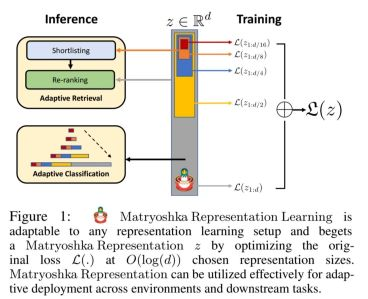

Mastroyska loss(wrapper) averages the base loss(MultiNegativeRanker-MNRE) across original dimensions and its downscaled version(MNRE claculation happens for each dimension but optimization/back_prop takes average loss in account).

#### **This helps as allows robust small dimension emebedds along with better representation of larger dimensin(then with just MNRE)**:-

- (i)This creates into account for ***reducing losses of all embeddings proportionally***. This creates a ***stable global minima with faster convergence that gives calibrated weights at all dimensions*** instead of each batch searching for their local minimas(***higher dimensions able to find deeper and broader valleys, while lower dimensions content with shallow/sharper minimas***).

- (ii)So when used together the smaller dimensions are forced to catch most prominent(coarse features) and efforts are made by base loss to maximize the alignment of positive pairs(reduce distance) while drive the negative pairs far away. This ways it gives robust context encapsulating lower dimensions embedding that has marginal loss of performance.--->**Tight smaller weights**.

- (iii)The **averaging also helps in regularizing of model** weights across all dimensions.
  - (a)**The Matryoshka Effect**:- Front dimensions to capture the most critical, high-level structural semantics (coarse features) to satisfy the lower-dimension loss terms.
  - (b)**Residual learning**:- where ***higher dimensions freed up to learn the subtle, fine-grained adjustments with greater alignment flexiblity***.

- (iv)**Enhanced Mathematical Separation in Vector Space**:-
  - (a)Greater alignment of true positives not only in lower space(points :- ii and iii(a)) but for higher dimensions(iii(b)). Automatically the False-positives decrease.
  - (b) **Tackles problem of curse of dimensioanlity in higher dimensions**--> The anchors are at large distance from their true positive like fasle positives. But since **Tight smaller weights** orient vectors prominently in a given direction, the given orientation retains in higher dimension(during **Residual learning**)  








In [ ]:
# Initial Loss
base_loss = MultipleNegativesRankingLoss(model)

# Matryoshka Loss Wrapper
train_loss = MatryoshkaLoss(
    model, base_loss, matryoshka_dims=matryoshka_dimensions
)

We'll use **(SentenceTransformer)Trainer wrapper** method to train our model(although can be done via **accelerator loop** for greater customization)Hyperparameters setting has been inspired from [Philip Schmidts'embedding fine-tune blog](https://www.philschmid.de/fine-tune-embedding-model-for-rag#3-define-loss-function-with-matryoshka-representation) with minute tune. Although there is scope of further experiment with discretion of user.

In [ ]:
'''
#to mount best fine-tuned model
from google.colab import drive
drive.mount('/content/gdrive')

path = "/content/gdrive/MyDrive"
'''

'\n#to mount best fine-tuned model\nfrom google.colab import drive\ndrive.mount(\'/content/gdrive\')\n\npath = "/content/gdrive/MyDrive"\n'

In [ ]:
# Training Arguments
args = SentenceTransformerTrainingArguments(
    output_dir="./nomic-embed-text-v1.5_Clinical-Trials_Matryoshka", # output directory and hugging face model ID()
    num_train_epochs=4,                                        # number of epochs
    per_device_train_batch_size=8,                            # Small physical batch size to avoid training OOM
    gradient_accumulation_steps=8,                            # Simulates an effective batch size of 8.
    per_device_eval_batch_size=32,                             # evaluation batch size
    warmup_ratio=0.1,                                          # warmup ratio
    learning_rate=2e-5,                                        # learning rate, 2e-5 is a good value
    lr_scheduler_type="cosine",                                # use cosine learning rate scheduler
    optim="adamw_torch_fused",                                 # use fused adamw optimizer
    #tf32=True,                                                # use tf32 precision(not supported by T4, better on NVIDIA ->Ampere,A-100 like newer GPUs)
    #bf16=True,                                                 # use bf16 precision(not supported by T4, better on TPU v5e-1, RTX-30 series,A-100 like newer GPUs)
    fp16=True,                                                 # most compatible with colab T4 and TPU v5e-1
    batch_sampler=BatchSamplers.NO_DUPLICATES,                 # MultipleNegativesRankingLoss benefits from no duplicate samples in a batch
    #eval_strategy="steps",
    #eval_steps=100,                                             # evaluate after each 60 steps
    #save_strategy="steps",
    #save_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",                                       # save after each epoch
    logging_steps=10,                                          # log every 10 steps
    save_total_limit=1,                                        # save only the last 1 models
    greater_is_better=True,                                    # higher the metric score(ndcg@10 here, better)
    load_best_model_at_end=True,                               # load the best model when training ends
    metric_for_best_model="eval_dim_128_cosine_ndcg@10",       # Optimizing for the best ndcg@10 score for the 128 dimension
    report_to="none"                                           # Turning off training logging for now, input 'wandb' etc. if desired.
)

take care to change train_dataset codeline as per source of dataset(Hugginface or pandas dataframe). ***First convrt the train_dataset df to HF.dataset.Dataset object and then feed the narrowed version(positive,anchor)to trainer ***

In [ ]:
train_dataset = Dataset.from_pandas(
    train_dataset,
    preserve_index=False
)# when_train_dataset from pandas as Sentencetransformer expects train_dataset to be a Hugging Face Dataset, not a Python dictionary/list

In [ ]:
# initialize (SentenceTransformer)trainer with relevant arg(loss, train data, train_arg)
trainer = SentenceTransformerTrainer(
    model=model,
    args=args,
    train_dataset=train_dataset.select_columns(["positive", "anchor"]),# used if dataset(HF dataset format)

    #eval_dataset=eval_dataset,(separate evaluation)
    #tokenizer=tokenizer,(tokenizer is already securely bundled inside the SentenceTransformer)
    loss=train_loss,
    evaluator=evaluator,)# we are considering SequentialEvaluator(matryoshka_evaluators), where mastryoshka _evaluators are list of instances of
    #InformationRetreivalEavluator called on all mashtryoska dimensions--->this proxies for "eval_dataset"(commeneted)



Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

intialize train

In [ ]:
# Start training
trainer.train()

dataset = dataset.select_columns(['anchor', 'positive', 'negative'])


Epoch,Training Loss,Validation Loss,Dim 768 Cosine Accuracy@1,Dim 768 Cosine Accuracy@3,Dim 768 Cosine Accuracy@5,Dim 768 Cosine Accuracy@10,Dim 768 Cosine Precision@1,Dim 768 Cosine Precision@3,Dim 768 Cosine Precision@5,Dim 768 Cosine Precision@10,Dim 768 Cosine Recall@1,Dim 768 Cosine Recall@3,Dim 768 Cosine Recall@5,Dim 768 Cosine Recall@10,Dim 768 Cosine Ndcg@10,Dim 768 Cosine Mrr@10,Dim 768 Cosine Map@100,Dim 512 Cosine Accuracy@1,Dim 512 Cosine Accuracy@3,Dim 512 Cosine Accuracy@5,Dim 512 Cosine Accuracy@10,Dim 512 Cosine Precision@1,Dim 512 Cosine Precision@3,Dim 512 Cosine Precision@5,Dim 512 Cosine Precision@10,Dim 512 Cosine Recall@1,Dim 512 Cosine Recall@3,Dim 512 Cosine Recall@5,Dim 512 Cosine Recall@10,Dim 512 Cosine Ndcg@10,Dim 512 Cosine Mrr@10,Dim 512 Cosine Map@100,Dim 256 Cosine Accuracy@1,Dim 256 Cosine Accuracy@3,Dim 256 Cosine Accuracy@5,Dim 256 Cosine Accuracy@10,Dim 256 Cosine Precision@1,Dim 256 Cosine Precision@3,Dim 256 Cosine Precision@5,Dim 256 Cosine Precision@10,Dim 256 Cosine Recall@1,Dim 256 Cosine Recall@3,Dim 256 Cosine Recall@5,Dim 256 Cosine Recall@10,Dim 256 Cosine Ndcg@10,Dim 256 Cosine Mrr@10,Dim 256 Cosine Map@100,Dim 128 Cosine Accuracy@1,Dim 128 Cosine Accuracy@3,Dim 128 Cosine Accuracy@5,Dim 128 Cosine Accuracy@10,Dim 128 Cosine Precision@1,Dim 128 Cosine Precision@3,Dim 128 Cosine Precision@5,Dim 128 Cosine Precision@10,Dim 128 Cosine Recall@1,Dim 128 Cosine Recall@3,Dim 128 Cosine Recall@5,Dim 128 Cosine Recall@10,Dim 128 Cosine Ndcg@10,Dim 128 Cosine Mrr@10,Dim 128 Cosine Map@100,Dim 64 Cosine Accuracy@1,Dim 64 Cosine Accuracy@3,Dim 64 Cosine Accuracy@5,Dim 64 Cosine Accuracy@10,Dim 64 Cosine Precision@1,Dim 64 Cosine Precision@3,Dim 64 Cosine Precision@5,Dim 64 Cosine Precision@10,Dim 64 Cosine Recall@1,Dim 64 Cosine Recall@3,Dim 64 Cosine Recall@5,Dim 64 Cosine Recall@10,Dim 64 Cosine Ndcg@10,Dim 64 Cosine Mrr@10,Dim 64 Cosine Map@100,Sequential Score
1,1.354603,No log,0.534943,0.637865,0.683609,0.726811,0.534943,0.212622,0.136722,0.072681,0.534943,0.637865,0.683609,0.726811,0.628623,0.597364,0.601066,0.526048,0.636595,0.678526,0.716645,0.526048,0.212198,0.135705,0.071665,0.526048,0.636595,0.678526,0.716645,0.620705,0.589880,0.594113,0.512071,0.621347,0.663278,0.717916,0.512071,0.207116,0.132656,0.071792,0.512071,0.621347,0.663278,0.717916,0.611739,0.578037,0.581577,0.491741,0.593393,0.645489,0.687421,0.491741,0.197798,0.129098,0.068742,0.491741,0.593393,0.645489,0.687421,0.586422,0.554403,0.559463,0.438374,0.547649,0.597205,0.654384,0.438374,0.182550,0.119441,0.065438,0.438374,0.547649,0.597205,0.654384,0.541356,0.505783,0.511160,0.541356
2,0.878376,No log,0.547649,0.653113,0.700127,0.740788,0.547649,0.217704,0.140025,0.074079,0.547649,0.653113,0.700127,0.740788,0.641648,0.610103,0.613222,0.536213,0.641677,0.687421,0.734435,0.536213,0.213892,0.137484,0.073443,0.536213,0.641677,0.687421,0.734435,0.632601,0.600289,0.603853,0.518424,0.636595,0.674714,0.724269,0.518424,0.212198,0.134943,0.072427,0.518424,0.636595,0.674714,0.724269,0.621455,0.588660,0.592448,0.499365,0.607370,0.653113,0.702668,0.499365,0.202457,0.130623,0.070267,0.499365,0.607370,0.653113,0.702668,0.599204,0.566223,0.570548,0.456163,0.570521,0.617535,0.670902,0.456163,0.190174,0.123507,0.067090,0.456163,0.570521,0.617535,0.670902,0.559806,0.524602,0.529623,0.559806
3,0.727133,No log,0.542567,0.658196,0.693774,0.742058,0.542567,0.219399,0.138755,0.074206,0.542567,0.658196,0.693774,0.742058,0.642242,0.610398,0.613746,0.538755,0.649301,0.686150,0.735705,0.538755,0.216434,0.137230,0.073571,0.538755,0.649301,0.686150,0.735705,0.636031,0.604346,0.608215,0.526048,0.650572,0.684879,0.731893,0.526048,0.216857,0.136976,0.073189,0.526048,0.650572,0.684879,0.731893,0.628375,0.595325,0.598758,0.491741,0.609911,0.656925,0.712834,0.491741,0.203304,0.131385,0.071283,0.491741,0.609911,0.656925,0.712834,0.598489,0.562268,0.566360,0.442186,0.569250,0.621347,0.674714,0.442186,0.189750,0.124269,0.067471,0.442186,0.569250,0.621347,0.6747

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [00:19<00:00, 19.07s/it]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/112 [00:00<?, ?it/s]

TrainOutput(global_step=444, training_loss=1.055193334549397, metrics={'train_runtime': 1783.1002, 'train_samples_per_second': 15.88, 'train_steps_per_second': 0.249, 'total_flos': 0.0, 'train_loss': 1.055193334549397, 'epoch': 4.0})

## Saving and pushing model

In [ ]:
# Save the best model based on our eval_dim_128_cosine_ndcg@10 criteria
trainer.save_model()#-->args.output_dir(already defined in training_arg)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# Upload model to hub
trainer.model.push_to_hub("vab46/nomic-embed-text-v1.5_Clinical-Trials_Matryoshka_final")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

'https://huggingface.co/vab46/nomic-embed-text-v1.5_Clinical-Trials_Matryoshka_final/commit/0aa6bbd0e7b2aef213f1f1eba2c4f89fcb366842'

## Evaluating Trained Model

In [ ]:
fine_tuned_model = SentenceTransformer(
    args.output_dir, device="cuda" if torch.cuda.is_available() else "cpu"
)

# Evaluate the model
#ft_results = evaluator(fine_tuned_model)
ft_results = evaluator(model)


Loading weights:   0%|          | 0/112 [00:00<?, ?it/s]

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [00:18<00:00, 18.35s/it]


...

Corpus Chunks: 100%|██████████| 1/1 [00:18<00:00, 18.48s/it]


Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [00:18<00:00, 18.42s/it]


In [ ]:


# Print header
print("Fine Tuned Model Evaluation Results")
print("-" * 85)
print(f"{'Metric':15} {'768d':>12} {'512d':>12} {'256d':>12} {'128d':>12} {'64d':>12}")
print("-" * 85)

#fine-tuned model metric evauation across dimension(with optimum k)

metrics_ls = ["accuracy", "recall", "precision", "map", "mrr", "ndcg"]

k_ls =[1,3,5,10, 100]#optimum k's

metric_k_dim_map_final={}
for metric in metrics_ls:
  for k in k_ls:
    if(k <10 and (metric =="map" or metric =="mrr" or metric =="ndcg")):
      continue

    elif(k==10 and metric=="map"):
      continue

    elif(k ==100):
      if(metric !="map"): continue

    metric_k = f"{metric}@{k}"

    metric_k_value =[] #popluate results on diff dimensions for given metric+k config
    for dim in matryoshka_dimensions:
      key = f"dim_{dim}_cosine_{metric_k}"
      metric_k_value.append(ft_results[key])#retreiving metric value

    metric_k_dim_map_final[metric_k] = metric_k_value

    if(metric_k =="ndcg@10"):
      metric_k = f"\033[1;4m{metric_k:15}\033[0m"#bold+underline(most_imp)
    elif(metric_k =="map@100" or metric_k =="mrr@10"):
      metric_k = f"\033[3;4m{metric_k:15}\033[0m"#italics+underline(2nd_most_imp)

    print(f"{metric_k:15}", end="  ")
    for val in metric_k_value:
        print(f"{val:12.4f}", end=" ")# 12 char in total with decimal point upto 4 float places
    print()

# Print sequential score
print("-" * 85)
print(f"{'seq_score:'} {ft_results['sequential_score']:2f}")

Fine Tuned Model Evaluation Results
-------------------------------------------------------------------------------------
Metric                  768d         512d         256d         128d          64d
-------------------------------------------------------------------------------------
accuracy@1             0.5476       0.5362       0.5184       0.4994       0.4562 
accuracy@3             0.6531       0.6417       0.6366       0.6074       0.5705 
accuracy@5             0.7001       0.6874       0.6747       0.6531       0.6175 
accuracy@10            0.7408       0.7344       0.7243       0.7027       0.6709 
recall@1               0.5476       0.5362       0.5184       0.4994       0.4562 
recall@3               0.6531       0.6417       0.6366       0.6074       0.5705 
recall@5               0.7001       0.6874       0.6747       0.6531       0.6175 
recall@10              0.7408       0.7344       0.7243       0.7027       0.6709 
precision@1            0.5476       0.5362     

### collating both pre and ft model metric on same eval set:-

In [ ]:
from pprint import pprint

In [ ]:
pprint(metric_k_dim_map_pre)

{'accuracy@1': [0.4320203303684879,
                0.4307496823379924,
                0.40025412960609913,
                0.37229987293519695,
                0.2947903430749682],
 'accuracy@10': [0.6226175349428208,
                 0.6099110546378653,
                 0.6073697585768743,
                 0.5743329097839899,
                 0.5235069885641678],
 'accuracy@3': [0.5285895806861499,
                0.5196950444726811,
                0.5019059720457433,
                0.47395171537484115,
                0.4167725540025413],
 'accuracy@5': [0.5743329097839899,
                0.5705209656925032,
                0.5501905972045743,
                0.5209656925031766,
                0.4650571791613723],
 'map@100': [0.4961522191532838,
             0.49205742000630737,
             0.46974931520275043,
             0.4410453528370101,
             0.3748523671366787],
 'mrr@10': [0.49167775962566296,
            0.48679736189266043,
            0.4647692664528748,
  

In [ ]:
metric_k_dim_map_ft =metric_k_dim_map_final
pprint(metric_k_dim_map_ft)

{'accuracy@1': [0.5476493011435832,
                0.5362134688691232,
                0.5184243964421855,
                0.4993646759847522,
                0.45616264294790343],
 'accuracy@10': [0.7407878017789072,
                 0.7344345616264295,
                 0.7242693773824651,
                 0.7026683608640406,
                 0.6709021601016518],
 'accuracy@3': [0.6531130876747141,
                0.6416772554002541,
                0.636594663278272,
                0.6073697585768743,
                0.5705209656925032],
 'accuracy@5': [0.7001270648030495,
                0.6874205844980941,
                0.6747141041931385,
                0.6531130876747141,
                0.6175349428208387],
 'map@100': [0.6132219854115385,
             0.6038531777197174,
             0.5924478219266626,
             0.5705480324974309,
             0.5296227395401097],
 'mrr@10': [0.6101031645186662,
            0.600288921159315,
            0.5886604747786449,
          

In [ ]:
if(list(metric_k_dim_map_pre.keys()) ==list(metric_k_dim_map_ft.keys())):#both have same keys
  print("True")

ls_metric_key = list(metric_k_dim_map_pre.keys())

k_int_dim={
    0:768,
    1:512,
    2:256,
    3:128,
    4:64
}

True


In [ ]:
import pandas as pd

In [ ]:
def process_metric_dimension(idx, pre_metric_dim, ft_metric_dim):

  comparison_map ={}
  comparison_map["metric"] = metric
  comparison_map["dimensions"] = k_int_dim[idx]
  comparison_map["base_value"] =pre_metric_dim
  comparison_map["ft_value"] = ft_metric_dim
  comparison_map["diff"] = ft_metric_dim - pre_metric_dim
  comparison_map["%change"] = (ft_metric_dim - pre_metric_dim)/pre_metric_dim*100
  return comparison_map

In [ ]:
comparison_ls=[]
for metric in ls_metric_key:

  count=0
  for pre_dim, ft_dim in zip(metric_k_dim_map_pre[metric], metric_k_dim_map_ft[metric]):
    comparison_map = process_metric_dimension(count, pre_dim, ft_dim)
    comparison_ls.append(comparison_map)
    count+=1

df_comparison = pd.DataFrame(comparison_ls)

In [ ]:
df_comparison.sort_values(by="metric", ascending=True, inplace=True)

In [ ]:
#5anchor_3chunk_iter1_base_ft_comparison.xlsx====>here anchor_id(id)---->unique_chunk_id map(global chunk id) used
#4anchor_1chunk_newAppr_base_ft_comparison_100step.xlsx===>here anchor_id(id)---->global_chunk_id(of consolidated chunks).

In [ ]:
df_comparison.to_excel("4anchor_1chunk_Cleanedfinal_base_ft_comparison_epoch.xlsx", engine= "openpyxl")

## Infernce on samples

In [ ]:
model_vab_broad_chunk = SentenceTransformer("vab46/nomic-embed-text-v1.5_Clinical-Trials_Matryoshka")
model_vab_chunk_final = SentenceTransformer("vab46/nomic-embed-text-v1.5_Clinical-Trials_Matryoshka_final")
mini_LM =SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
model_e5_large = SentenceTransformer("intfloat/e5-large-v2")
model_baai = SentenceTransformer("BAAI/bge-m3")

modules.json:   0%|          | 0.00/277 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/284 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/73.2k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/241 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.53k [00:00<?, ?B/s]

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

In [ ]:
incl_query_list =['''Does the participant demonstrate cognitive performance within the age- and
education-adjusted normal range on the required neuropsychological assessments, with no clinical suspicion of dementia?''',
'''Does the participant meet the trial requirements for demographic matching (age and gender) and have the required social insurance coverage?''']

excl_query_list=['''Does the participant have any history of neurological, neurodegenerative, vascular, inflammatory,
intracranial, pituitary, or other systemic/ocular disease that could affect study eligibility or the planned eye examination?''',
'''Does the participant have any condition, cognitive/behavioral impairment, diabetes, or legal status that prevents
completion of the study procedures or provision of valid informed consent?''']


In [ ]:
incl_chunk=''' Absence of suspicion of dementia, based on normal performance according to age and educational level at neuropsychological testing defined as:
Free recall ≥17 and total recall ≥40 for the Free and Cued Selective Reminding Test (Grober and Buschke test 52) MMSE ≥ norm for age and educational level (defined by mean - 1 SD)
Isaac's set test ≥ norm for age and educational level (defined by mean - 1 SD)
Matched to age and gender of the cases
Patient benefiting from social insurance'''

excl_chunk='''History of Parkinson's disease or other neurodegenerative disorder
History of Horton's disease
History of inflammatory neuropathies (in particular Devic's disease, multiple sclerosis)
History of vascular ischemic neuropathies and chronic intracranial hypertension
History of pituitary tumors
Presence of diseases (systemic and/or ocular diseases) or behavioural or cognitive symptoms incompatible with eye examination
Known diabetes
Person under tutorship or curatorship, person unable to express consent'''

In [ ]:
def similarity(model, inclusion_query, exclusion_query, inclusion_chunk, exclusion_chunk):
  incl_query_embed = model.encode(inclusion_query, normalize_embeddings=True)
  excl_query_embed = model.encode(exclusion_query, normalize_embeddings=True)
  incl_chunk_embed = model.encode(inclusion_chunk, normalize_embeddings=True)
  excl_chunk_embed = model.encode(exclusion_chunk, normalize_embeddings=True)

  #similar question and chunk
  for i,incl_vec in enumerate(incl_query_embed):
      print(f"similarity b/w {i}th inclusion query and inclusion_chunk is:-{model.similarity(incl_vec, incl_chunk_embed)}")

  for i,excl_vec in enumerate(excl_query_embed):
      print(f"similarity b/w {i}th exclusion query and exclusion_chunk is:-{model.similarity(excl_vec, excl_chunk_embed)}")

  print('+'*70)

  #mon-similar question and chunk

  for i,incl_vec in enumerate(incl_query_embed):
      print(f"similarity b/w {i}th inclusion query and exclusion_chunk is:-{model.similarity(incl_vec, excl_chunk_embed)}")

  for i,excl_vec in enumerate(excl_query_embed):
      print(f"similarity b/w {i}th exclusion query and inclusion_chunk is:-{model.similarity(excl_vec, incl_chunk_embed)}")



In [ ]:
model_list =[model_vab_broad_chunk, model_vab_chunk_final, mini_LM, model_e5_large, model_baai]
for model_idx in range(len(model_list)):
  model = model_list[model_idx]
  print(f"model_name:-{'vab_broad_chunk' if model_idx==0 else 'model_vab_chunk_final' if model_idx==1 else 'mini_LM' if model_idx==2 else 'e5_large' if model_idx==3 else 'baai_b3'}:-{'-'*70}")

  similarity(model, incl_query_list, excl_query_list, incl_chunk, excl_chunk)
  print('~'*80)

model_name:-vab_broad_chunk:-----------------------------------------------------------------------
similarity b/w 0th inclusion query and inclusion_chunk is:-tensor([[0.7706]])
similarity b/w 1th inclusion query and inclusion_chunk is:-tensor([[0.4662]])
similarity b/w 0th exclusion query and exclusion_chunk is:-tensor([[0.5973]])
similarity b/w 1th exclusion query and exclusion_chunk is:-tensor([[0.5418]])
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
similarity b/w 0th inclusion query and exclusion_chunk is:-tensor([[0.3625]])
similarity b/w 1th inclusion query and exclusion_chunk is:-tensor([[0.1784]])
similarity b/w 0th exclusion query and inclusion_chunk is:-tensor([[0.3526]])
similarity b/w 1th exclusion query and inclusion_chunk is:-tensor([[0.3994]])
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
model_name:-model_vab_chunk_final:-----------------------------------------------------------------------
similarity b/w 0th